In [9]:
######################################### 
# Carregar data set e criar dataloader  #
#########################################

In [7]:
import torch
from torchvision.datasets import CIFAR10
from torchvision.transforms import transforms

In [8]:
# --- Normalizador para ResNet --- 
transformador = transforms.Compose([
    transforms.Resize(256), 
    transforms.CenterCrop(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [23]:
# --- Obtendo o Dataset e Carregando os Dados ---

# Dados de treino
conjunto_treino = CIFAR10(
    root='./data', 
    train=True,
    download=True, 
    transform=transformador,
)
carregador_treino = torch.utils.data.DataLoader(
    dataset=conjunto_treino,
    batch_size=32,
    shuffle=True, 
)

# Dados de teste
conjunto_teste = CIFAR10(
    root='./data', 
    train=False,
    download=True, 
    transform=transformador,
)
carregador_teste = torch.utils.data.DataLoader(
    dataset=conjunto_teste,
    batch_size=32,
    shuffle=True, 
)

# Definindo as classes
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


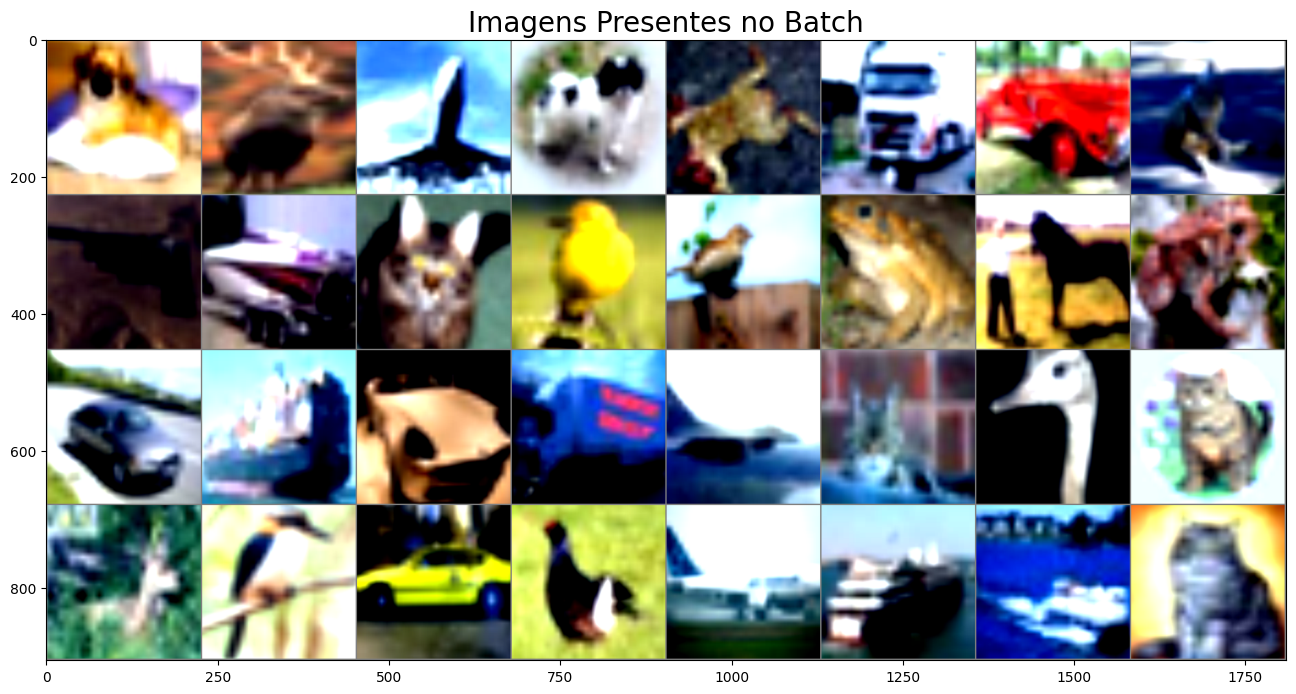

In [34]:
# --- Visualizando um Batch --- 

import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

def imshow(img):
    """Essa função recebe tensores de imagens transformadas e plota um grid com as imagens."""
    img = img / 2 + 0.5
    npimg = img.numpy()
    fig, ax = plt.subplots(figsize=(16,9))
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title("Imagens Presentes no Batch", fontsize=20)
    plt.show()


# Acessando um batch de imagens aleatórias do conjunto de treino
dataiter = iter(carregador_treino)
images, _ = next(dataiter)

# Mostrando as imagens do batch
imshow(make_grid(images))

In [2]:
# --- Carregar Modelo ResNet --- 